# Bias–Variance Analysis

This notebook explores the tradeoff between model bias and variance using mammal brain- and body-weight data. The analysis is adapted from Kevin Markham's [DAT8 bias–variance notebook](https://github.com/justmarkham/DAT8/blob/master/notebooks/08_bias_variance.ipynb).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set() # Switch to Seaborn defaults when plotting

# Render plots inline
%matplotlib inline

## Brain and body weight

The [dataset](http://people.sc.fsu.edu/~jburkardt/datasets/regression/x01.txt) contains average body and brain weights for 62 mammal species.

In [2]:
url = 'http://people.sc.fsu.edu/~jburkardt/datasets/regression/x01.txt'
col_names = ['id', 'brain', 'body']
mammals = pd.read_csv(url, sep='\s+', skiprows=33, names=col_names, index_col='id')
mammals.head()

,brain,body
id,,
1,3.385,44.5
2,0.480,15.5
3,1.350,8.1
4,465.000,423.0
5,36.330,119.5


One observation reports a brain weight greater than its body weight, indicating a likely data-quality issue. The invalid row is removed before modeling.

In [4]:
# Remove observations where brain weight exceeds body weight


mammals = mammals.drop(mammals[mammals['brain'] >= mammals['body']].index)
mammals.head()

,brain,body
id,,
1,3.385,44.5
2,0.480,15.5
3,1.350,8.1
5,36.330,119.5
6,27.660,115.0


Summary statistics provide a quick view of the cleaned dataset.

In [5]:
mammals.describe()

,brain,body
count,59.000000,59.000000
mean,84.982695,190.496949
std,342.726611,626.724553
min,0.005000,0.140000
25%,0.515000,3.950000
50%,3.000000,15.500000
75%,31.330000,117.250000
max,2547.000000,4603.000000


The analysis focuses on mammals with body weights below 200 to reduce the influence of extreme values.

In [6]:
# Retain mammals with body weights below 200
mammals = mammals[mammals['body'] < 200]
mammals.shape

(50, 2)

A scatterplot visualizes the relationship between body and brain weight in the filtered dataset.

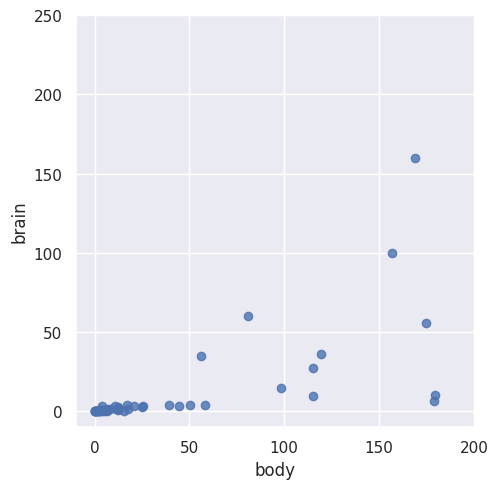

In [7]:
# Plot brain weight against body weight
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None, fit_reg=False)

# Use consistent axis limits for comparison
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

### Linear prediction

A linear regression model provides a baseline estimate of brain weight from body weight. For illustration, the fitted line is used to predict the brain weight of a mammal with an average body weight of 100.

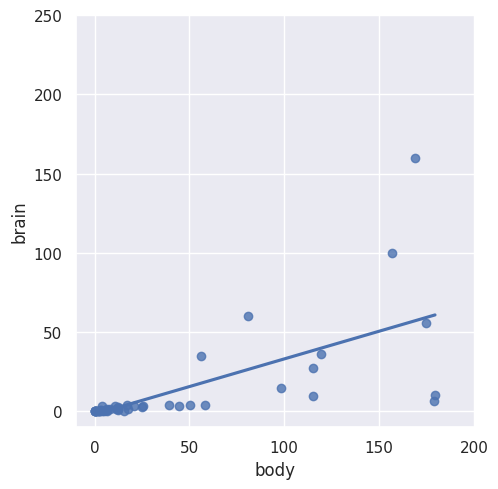

In [8]:
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None)
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

The fitted line predicts a brain weight of approximately 45 when body weight is 100. This simple model captures the overall direction of the relationship but does not closely fit every observation.

### Sensitivity to sampling

To examine variance, the observations are randomly divided into two samples and the model is fitted independently to each sample.

In [9]:
# Set a random seed for reproducibility
np.random.seed(0)

# Randomly assign observations to one of two samples
mammals['universe'] = np.random.randint(1, 3, len(mammals)) # Add a column of randomly selected integers starting at 1 and less than 3
mammals.head()

,brain,body,universe
id,,,
1,3.385,44.5,1
2,0.480,15.5,2
3,1.350,8.1,2
5,36.330,119.5,1
6,27.660,115.0,2


Each sample contains different species. Comparing the fitted models shows how sensitive the modeling approach is to the observations available during training.

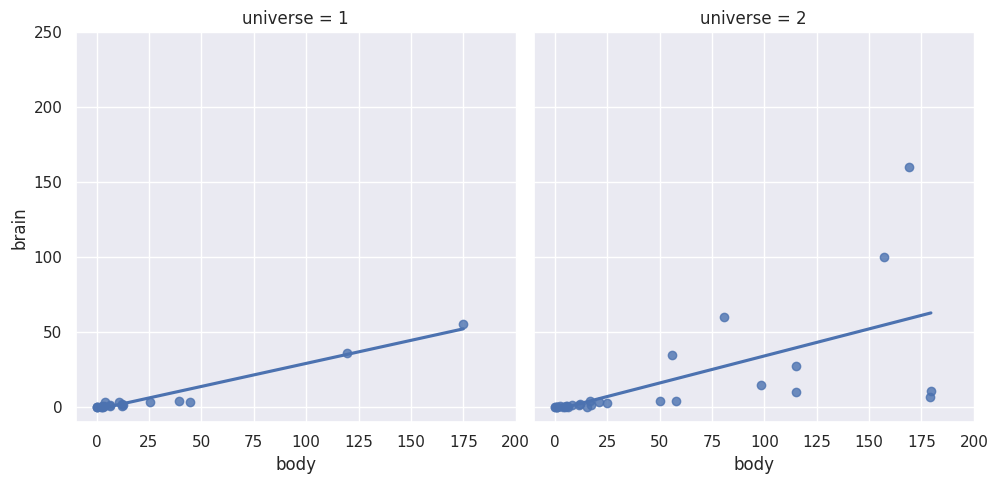

In [10]:
# Fit each sample in a separate panel
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None, col='universe')
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

The two linear fits are similar and produce predictions near 45 for a body weight of 100. Overlaying them makes their stability easier to compare.

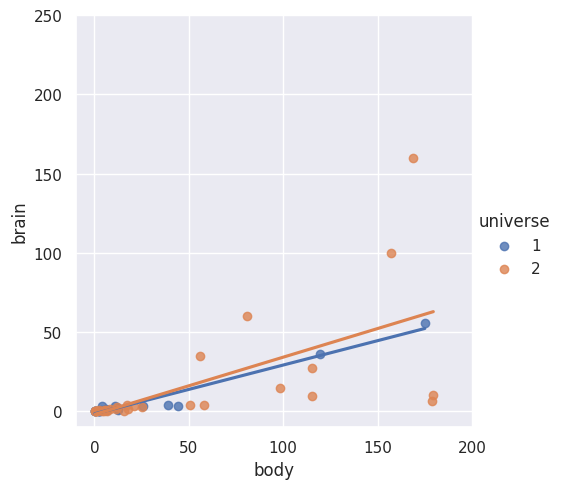

In [11]:
# Overlay both sample-specific fits
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None, hue='universe')
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

The linear model demonstrates relatively high bias and low variance:

- **High bias:** the straight line does not capture the data closely.
- **Low variance:** the fitted relationship changes little across the two samples.

### Eighth-degree polynomial

An eighth-degree polynomial illustrates the opposite behavior: a flexible model that can fit each sample closely.

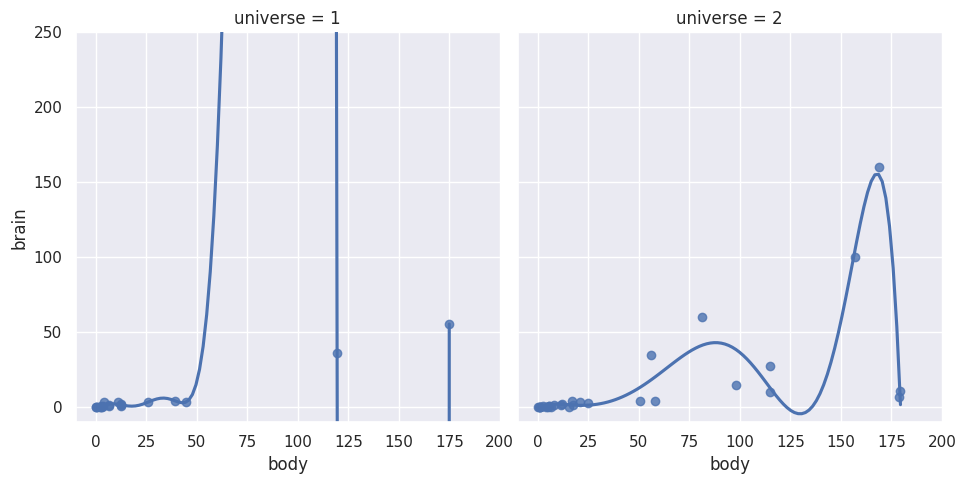

In [13]:
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None, col='universe', order=8)
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

The polynomial models demonstrate low bias and high variance:

- **Low bias:** each curve follows its training sample closely.
- **High variance:** the fitted curves and their predictions differ substantially between samples.

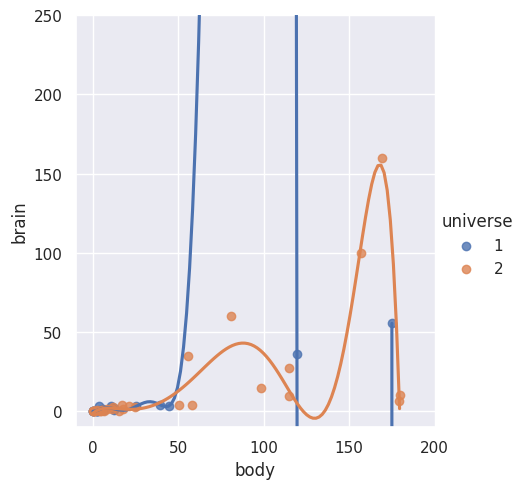

In [14]:
# Overlay the eighth-degree polynomial fits
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None, hue='universe', order=8)
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

### A middle ground

A second-degree polynomial provides a less flexible alternative that may balance fit quality and stability.

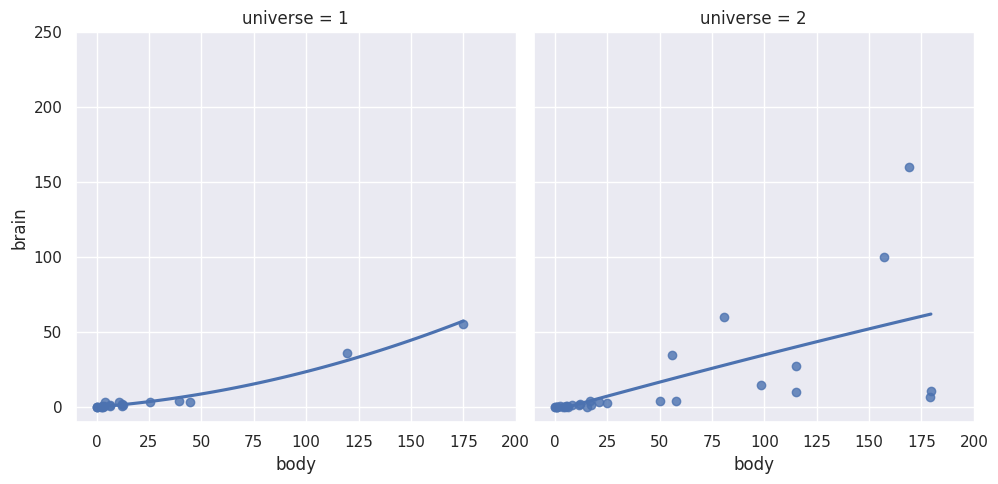

In [15]:
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None, col='universe', order=2)
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

The quadratic models fit the relationship better than a straight line while remaining more consistent across samples than the eighth-degree polynomials.

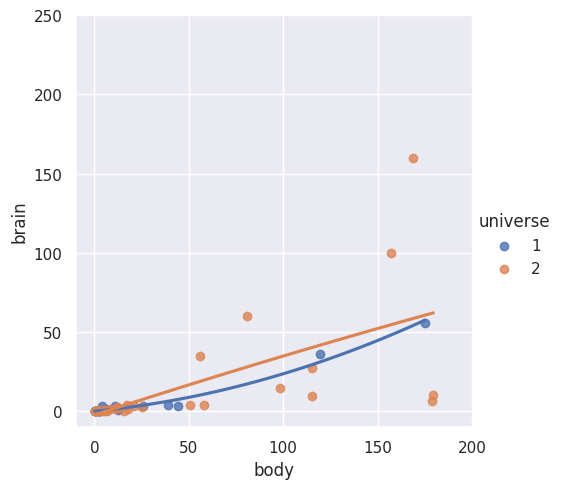

In [16]:
# Overlay the quadratic fits
ax = sns.lmplot(x='body', y='brain', data=mammals, ci=None, hue='universe', order=2)
ax.set(xlim=(-10, 200))
ax.set(ylim=(-10, 250))

The bias–variance tradeoff describes the balance between underfitting and sensitivity to training data. A useful model captures the underlying pattern while remaining stable enough to generalize to unseen observations.

### Key concepts

- **Bias** is systematic error caused by assumptions that are too restrictive to capture the underlying relationship.
- **Variance** is sensitivity to changes in the training sample.